# Project 1: Data Analysis 

## 1 Aggregate inflation in Denmark

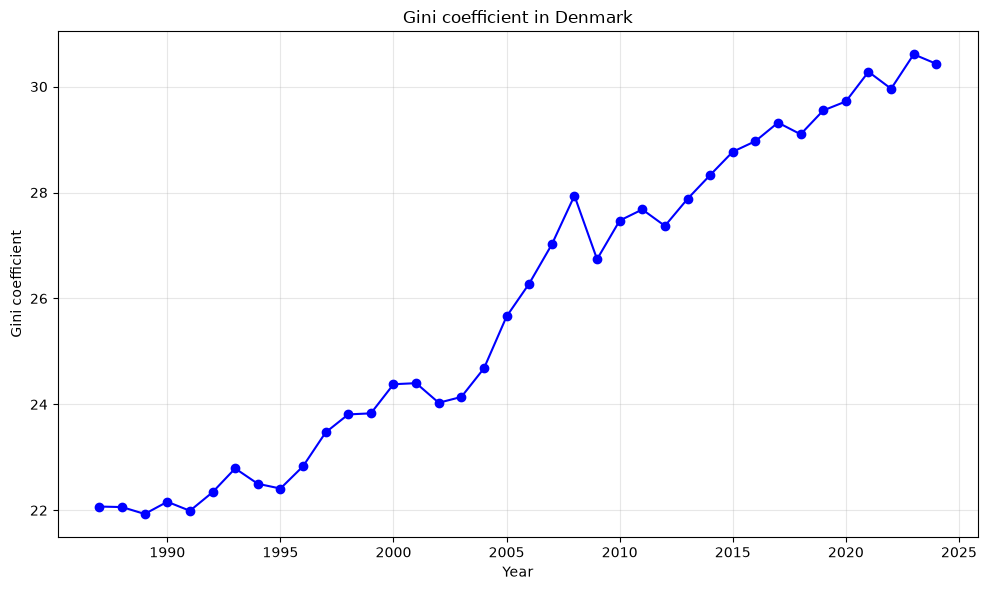

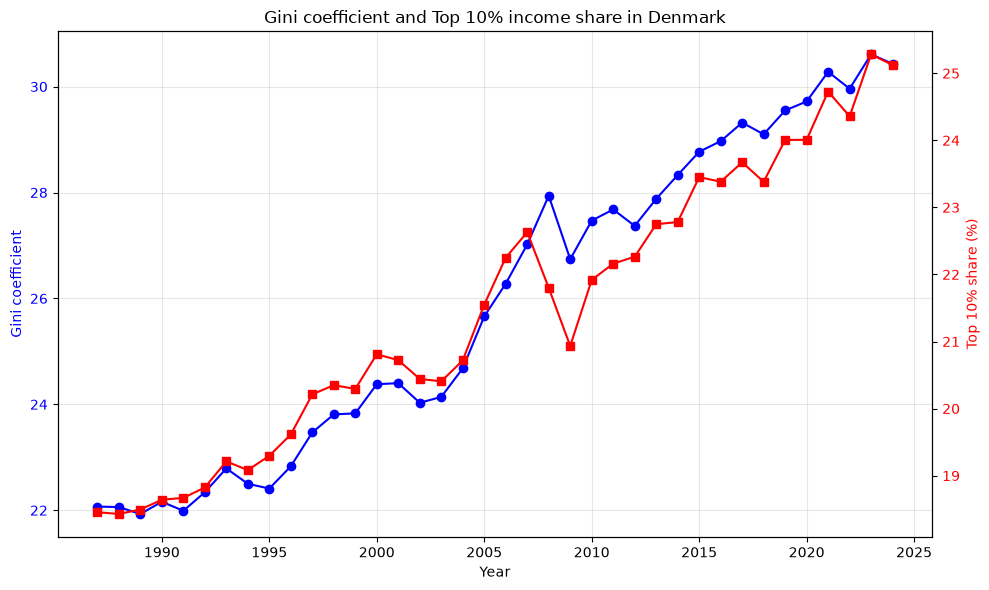

Correlation: 0.982
Linear coefficients:
beta0 = 21.0428
beta1 = 0.2635
Quadratic coefficients:
beta0 = 21.3042
beta1 = 0.2200
beta2 = 0.001178
Linear coefficients: 0.264, 21.043
Quadratic coefficients: 0.001, 0.220, 21.304
Year 2030: linear = 32.375, quadratic = 32.941
Year 2040: linear = 35.011, quadratic = 36.271


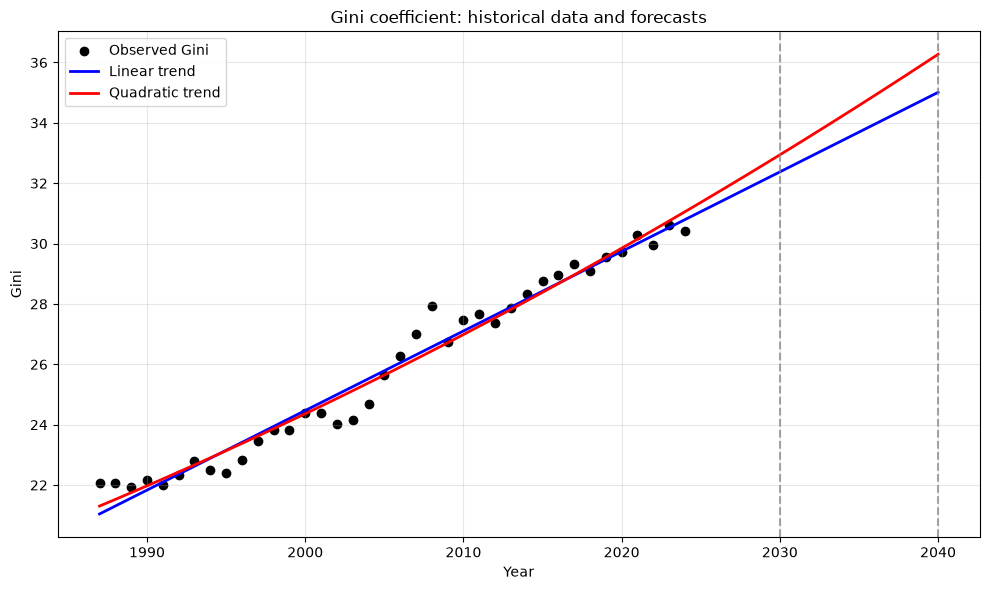

Correlation across municipalities in 2024: 0.975
Most unequal:
      municipality   Gini
24        Gentofte  49.04
73       Rudersdal  47.31
92           Vejen  46.32
43        Hørsholm  40.07
56  Lyngby-Taarbæk  39.28
20   Frederiksberg  36.54
50       København  34.97
2           Aarhus  33.43
18     Fredensborg  32.76
33       Helsingør  30.55

Most equal:
       municipality   Gini
14  Faaborg-Midtfyn  23.77
12           Egedal  23.85
8          Bornholm  24.03
17             Faxe  24.09
16         Favrskov  24.41
31          Halsnæs  24.41
5            Assens  24.46
32        Hedensted  24.58
3       Albertslund  24.66
65            Odder  24.70


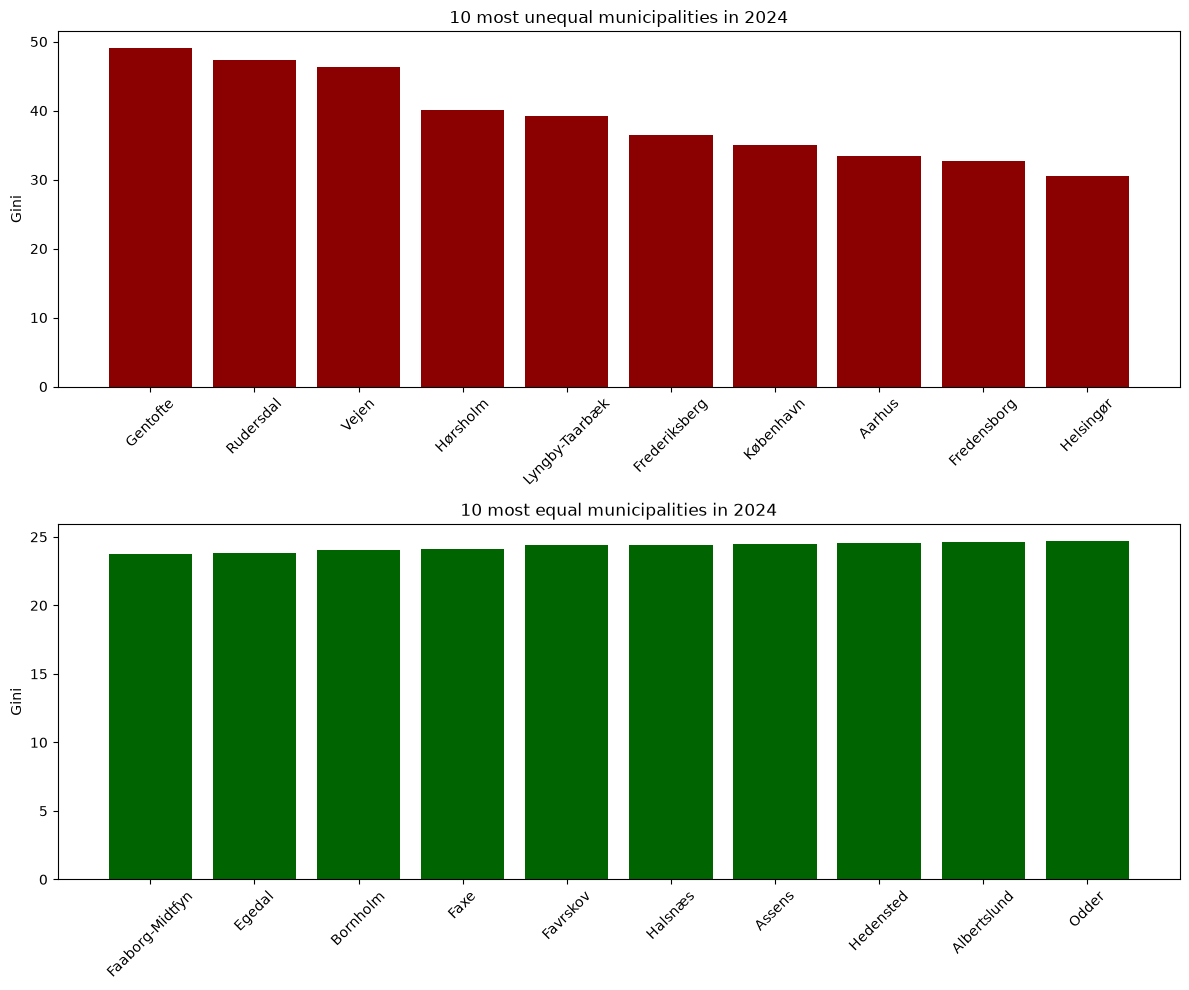


Largest increase in Gini:
      municipality  gini_first  gini_last  change
92           Vejen       21.20      46.32   25.12
73       Rudersdal       29.05      47.31   18.26
24        Gentofte       31.10      49.04   17.94
56  Lyngby-Taarbæk       24.97      39.28   14.31
50       København       23.05      34.97   11.92
43        Hørsholm       28.39      40.07   11.68
18     Fredensborg       21.17      32.76   11.59
2           Aarhus       22.10      33.43   11.33
20   Frederiksberg       25.28      36.54   11.26
90      Vallensbæk       15.90      26.70   10.80

Smallest change in Gini:
       municipality  gini_first  gini_last  change
15             Fanø       25.67      26.34    0.67
97              Ærø       24.63      26.98    2.35
17             Faxe       21.64      24.09    2.45
57             Læsø       22.81      25.41    2.60
8          Bornholm       21.31      24.03    2.72
14  Faaborg-Midtfyn       20.88      23.77    2.89
81             Sorø       22.24      25.

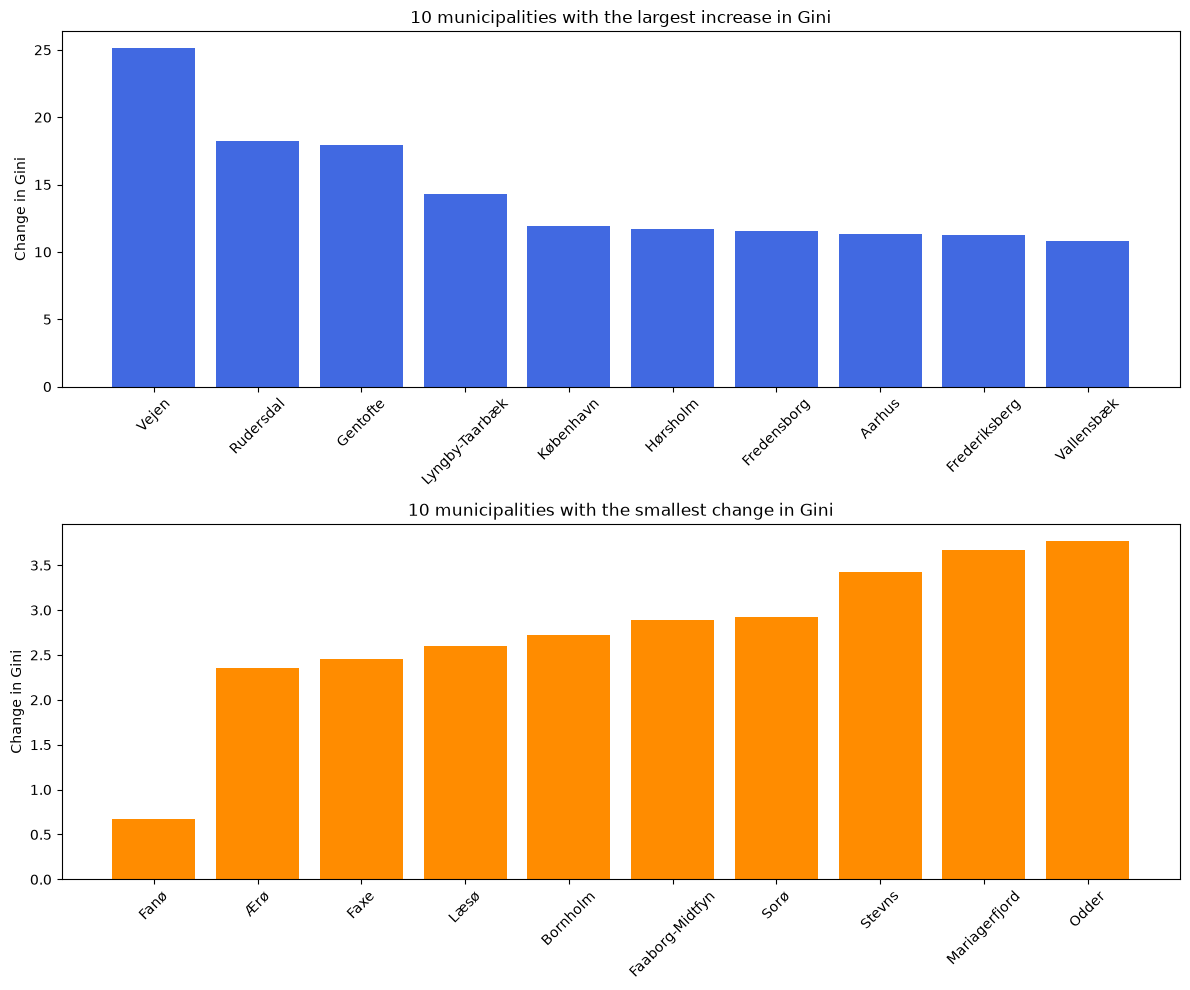

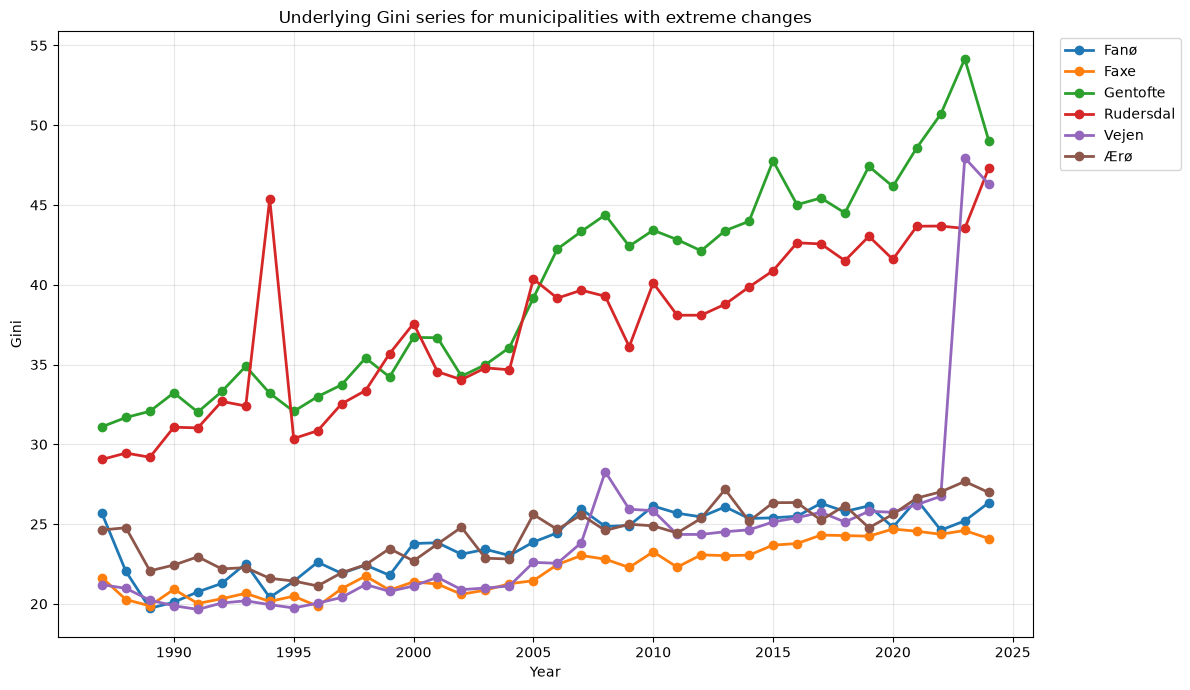


Interpretation: the municipality-level correlation is very strong and positive,
which matches the national pattern over time. The unequal municipalities are mainly
wealthy suburban municipalities, while the more equal ones tend to be smaller or
less affluent municipalities. The largest changes mostly reflect municipal changes
over time rather than one-off extreme incomes, so the time-series plots are important
for checking whether a ranking is driven by a single unusually large income year.


In [99]:
# -------------------------------------------------
# Imports and data
# -------------------------------------------------

# Imprts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Indlæser og sortere data
url41 = "https://api.statbank.dk/v1/data/IFOR41/CSV?ULLIG=70&KOMMUNEDK=*&Tid=*"
gini_raw = pd.read_csv(url41, sep=";")

gini_raw = gini_raw[["KOMMUNEDK", "TID", "INDHOLD"]].copy()
gini_raw.columns = ["municipality", "Year", "Gini"]

gini_raw["municipality"] = gini_raw["municipality"].astype(str)
gini_raw["Year"] = pd.to_numeric(gini_raw["Year"], errors="coerce")
gini_raw["Gini"] = pd.to_numeric(
    gini_raw["Gini"].astype(str).str.replace(",", "."),
    errors="coerce"
)
gini_raw = gini_raw.dropna().sort_values(["municipality", "Year"]).reset_index(drop=True)

url32 = "https://api.statbank.dk/v1/data/IFOR32/CSV?DECILGEN=*&KOMMUNEDK=*&Tid=*"
decile_raw = pd.read_csv(url32, sep=";")

decile_raw = decile_raw[["KOMMUNEDK", "DECILGEN", "TID", "INDHOLD"]].copy()
decile_raw.columns = ["municipality", "decile", "Year", "income"]

decile_raw["municipality"] = decile_raw["municipality"].astype(str)
decile_raw["Year"] = pd.to_numeric(decile_raw["Year"], errors="coerce")
decile_raw["income"] = pd.to_numeric(
    decile_raw["income"].astype(str).str.replace(",", "."),
    errors="coerce"
)
decile_raw["decile"] = decile_raw["decile"].astype(str).str.extract(r"(\d+)")
decile_raw["decile"] = pd.to_numeric(decile_raw["decile"], errors="coerce")
decile_raw = decile_raw.dropna().sort_values(["municipality", "Year", "decile"]).reset_index(drop=True)


# -------------------------------------------------
# 1.1: Gini + Top 10% share (national data)
# -------------------------------------------------

# National data: keep only "Hele landet"
gini_nat = gini_raw[
    gini_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values("Year").reset_index(drop=True)

decile_nat = decile_raw[
    decile_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["Year", "decile"]).reset_index(drop=True)

decile_pivot = decile_nat.pivot_table(
    index="Year",
    columns="decile",
    values="income",
    aggfunc="first"
).sort_index()

decile_pivot = decile_pivot.reindex(columns=range(1, 11), fill_value=np.nan)
top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)

top10 = top10_share.reset_index()
top10.columns = ["Year", "Top10Share"]

merged = gini_nat.merge(top10, on="Year", how="inner")

# Figure 1: Gini coefficient over time
plt.figure(figsize=(10, 6))
plt.plot(merged["Year"], merged["Gini"], color="blue", marker="o")
plt.title("Gini coefficient in Denmark")
plt.xlabel("Year")
plt.ylabel("Gini coefficient")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Gini and top 10% share in the same figure
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(merged["Year"], merged["Gini"], color="blue", marker="o", label="Gini coefficient")
ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(merged["Year"], merged["Top10Share"] * 100, color="red", marker="s", label="Top 10% share")
ax2.set_ylabel("Top 10% share (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Gini coefficient and Top 10% income share in Denmark")
fig.tight_layout()
plt.show()

corr = merged["Gini"].corr(merged["Top10Share"])
print(f"Correlation: {corr:.3f}")

# -------------------------------------------------
# 1.2: Prediction
# -------------------------------------------------

# Minimize SSE with scipy.optimize.minimize
gini_fit = gini_nat.copy()
gini_fit["t"] = gini_fit["Year"] - gini_fit["Year"].min()

t = gini_fit["t"].to_numpy()
y = gini_fit["Gini"].to_numpy()

# Linear trend
def sse_linear(beta, t, y):
    y_hat = beta[0] + beta[1] * t
    return np.sum((y - y_hat) ** 2)

result_linear = minimize(
    sse_linear,
    x0=[20, 0.1],
    args=(t, y)
)

beta_linear = result_linear.x
print("Linear coefficients:")
print(f"beta0 = {beta_linear[0]:.4f}")
print(f"beta1 = {beta_linear[1]:.4f}")

# Quadratic trend
def sse_quadratic(beta, t, y):
    y_hat = beta[0] + beta[1] * t + beta[2] * t**2
    return np.sum((y - y_hat) ** 2)

result_quadratic = minimize(
    sse_quadratic,
    x0=[20, 0.1, 0.001],
    args=(t, y)
)

beta_quadratic = result_quadratic.x
print("Quadratic coefficients:")
print(f"beta0 = {beta_quadratic[0]:.4f}")
print(f"beta1 = {beta_quadratic[1]:.4f}")
print(f"beta2 = {beta_quadratic[2]:.6f}")

# Minimize with polyfit
coef_lin = np.polyfit(t, y, 1)
coef_quad = np.polyfit(t, y, 2)

print(f"Linear coefficients: {coef_lin[0]:.3f}, {coef_lin[1]:.3f}")
print(f"Quadratic coefficients: {coef_quad[0]:.3f}, {coef_quad[1]:.3f}, {coef_quad[2]:.3f}")

# Forecasts for 2030 and 2040 with a for loop
for year in [2030, 2040]:
    tau = year - gini_fit["Year"].min()
    lin_pred = beta_linear[0] + beta_linear[1] * tau
    quad_pred = beta_quadratic[0] + beta_quadratic[1] * tau + beta_quadratic[2] * tau**2
    print(f"Year {year}: linear = {lin_pred:.3f}, quadratic = {quad_pred:.3f}")

# Plot observed data + fitted trends
years_future = np.arange(gini_fit["Year"].min(), 2041)
t_future = years_future - gini_fit["Year"].min()

linear_fit = beta_linear[0] + beta_linear[1] * t_future
quadratic_fit = beta_quadratic[0] + beta_quadratic[1] * t_future + beta_quadratic[2] * t_future**2

plt.figure(figsize=(10, 6))
plt.scatter(gini_fit["Year"], gini_fit["Gini"], color="black", label="Observed Gini")
plt.plot(years_future, linear_fit, color="blue", linewidth=2, label="Linear trend")
plt.plot(years_future, quadratic_fit, color="red", linewidth=2, label="Quadratic trend")
plt.axvline(2030, color="gray", linestyle="--", alpha=0.7)
plt.axvline(2040, color="gray", linestyle="--", alpha=0.7)
plt.title("Gini coefficient: historical data and forecasts")
plt.xlabel("Year")
plt.ylabel("Gini")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 1.3: Municipalities
# -------------------------------------------------

# Reuse the already cleaned raw data and filter out the national aggregate
gini = gini_raw[
    ~gini_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["municipality", "Year"]).reset_index(drop=True)

decile = decile_raw[
    ~decile_raw["municipality"].str.contains("Hele landet", case=False, na=False)
].copy().sort_values(["municipality", "Year", "decile"]).reset_index(drop=True)

# 2) Top 10% share
decile_pivot = decile.pivot_table(
    index=["municipality", "Year"],
    columns="decile",
    values="income",
    aggfunc="first"
).reindex(columns=range(1, 11), fill_value=np.nan)

top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)
top10 = top10_share.reset_index()
top10.columns = ["municipality", "Year", "Top10Share"]

# 3) Latest year and correlation across municipalities
latest_year = max(gini["Year"].max(), top10["Year"].max())
gini_latest = gini[gini["Year"] == latest_year].copy()
top10_latest = top10[top10["Year"] == latest_year].copy()

df = gini_latest.merge(top10_latest, on=["municipality", "Year"], how="inner")

corr = df["Gini"].corr(df["Top10Share"])
print(f"Correlation across municipalities in {latest_year}: {corr:.3f}")

# 4) Most unequal / most equal municipalities in the most recent year
most_unequal = df.sort_values("Gini", ascending=False).head(10).copy()
most_equal = df.sort_values("Gini", ascending=True).head(10).copy()

print("Most unequal:")
print(most_unequal[["municipality", "Gini"]])

print("\nMost equal:")
print(most_equal[["municipality", "Gini"]])

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(most_unequal["municipality"], most_unequal["Gini"], color="darkred")
axes[0].set_title(f"10 most unequal municipalities in {latest_year}")
axes[0].set_ylabel("Gini")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(most_equal["municipality"], most_equal["Gini"], color="darkgreen")
axes[1].set_title(f"10 most equal municipalities in {latest_year}")
axes[1].set_ylabel("Gini")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 5) Largest and smallest change in Gini over time
gini_change = (
    gini.groupby("municipality")
    .agg(gini_first=("Gini", "first"), gini_last=("Gini", "last"))
    .reset_index()
)
gini_change["change"] = gini_change["gini_last"] - gini_change["gini_first"]

largest_change = gini_change.sort_values("change", ascending=False).head(10)
smallest_change = gini_change.sort_values("change", ascending=True).head(10)

print("\nLargest increase in Gini:")
print(largest_change[["municipality", "gini_first", "gini_last", "change"]])

print("\nSmallest change in Gini:")
print(smallest_change[["municipality", "gini_first", "gini_last", "change"]])

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].bar(largest_change["municipality"], largest_change["change"], color="royalblue")
axes[0].set_title("10 municipalities with the largest increase in Gini")
axes[0].set_ylabel("Change in Gini")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(smallest_change["municipality"], smallest_change["change"], color="darkorange")
axes[1].set_title("10 municipalities with the smallest change in Gini")
axes[1].set_ylabel("Change in Gini")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 1.4: Extensions
# -------------------------------------------------

# Also inspect the underlying series for the municipalities with the largest/smallest changes
selected_change_municipalities = list(largest_change["municipality"].head(3)) + list(smallest_change["municipality"].head(3))
change_series_selected = gini[gini["municipality"].isin(selected_change_municipalities)].copy()

fig, ax = plt.subplots(figsize=(12, 7))
for muni, grp in change_series_selected.groupby("municipality"):
    ax.plot(grp["Year"], grp["Gini"], marker="o", linewidth=2, label=muni)
ax.set_title("Underlying Gini series for municipalities with extreme changes")
ax.set_xlabel("Year")
ax.set_ylabel("Gini")
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nInterpretation: the municipality-level correlation is very strong and positive,\nwhich matches the national pattern over time. The unequal municipalities are mainly\nwealthy suburban municipalities, while the more equal ones tend to be smaller or\nless affluent municipalities. The largest changes mostly reflect municipal changes\nover time rather than one-off extreme incomes, so the time-series plots are important\nfor checking whether a ranking is driven by a single unusually large income year.")


## 2 Simulating the income distribution

Mean income: 100066.73
Median income: 88180.20
Std. dev. of income: 53373.28
Min income: 10054.57
Max income: 805501.42


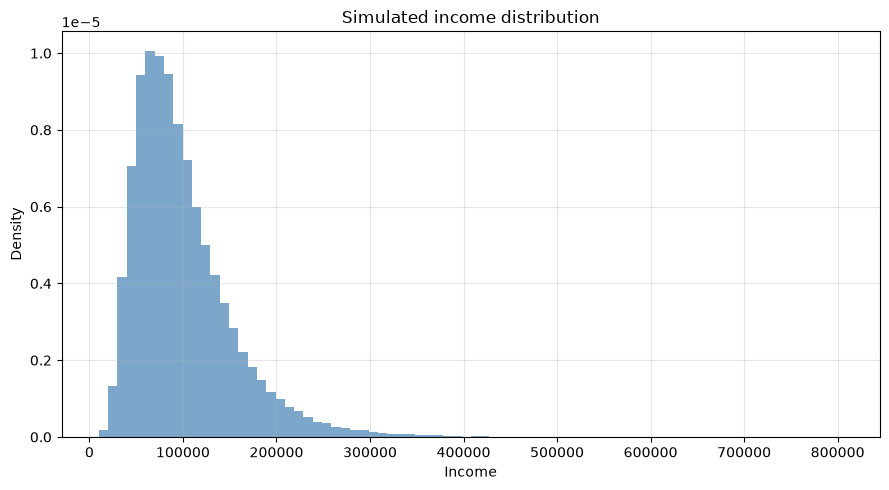

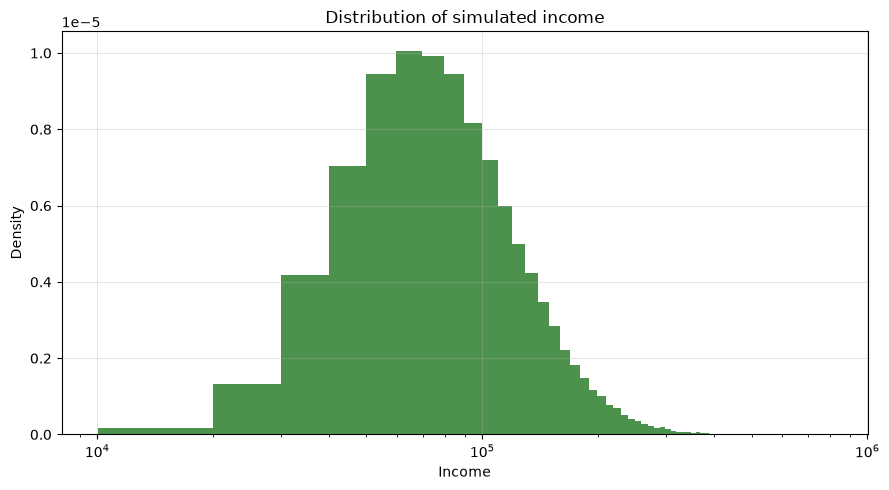

Gini coefficient: 0.277


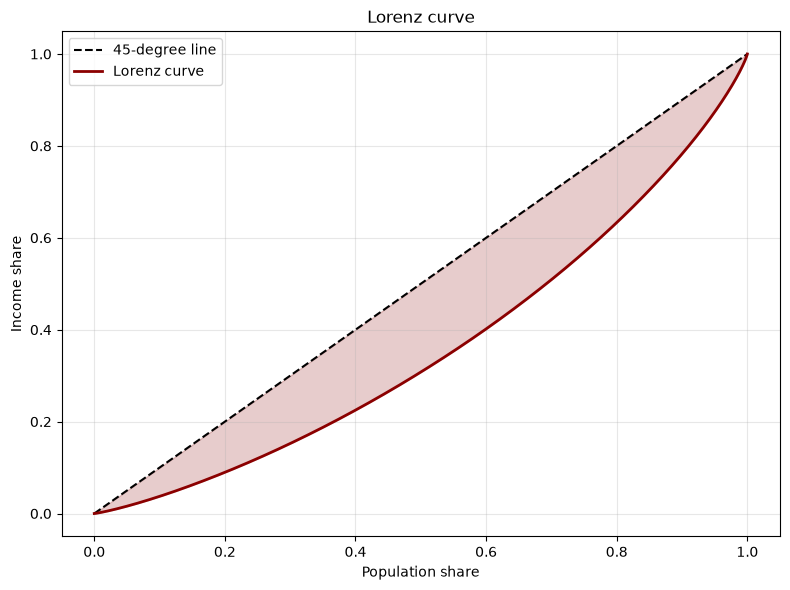

   sigma_psi  mean_income   std_income    gini
0        0.1   99979.4786   10051.0573  0.0566
1        0.3  100087.8690   30612.7086  0.1673
2        0.5   99888.0383   52991.2730  0.2753
3        0.8  100294.8339   95105.5734  0.4290
4        1.2  100215.0047  176975.3580  0.6042


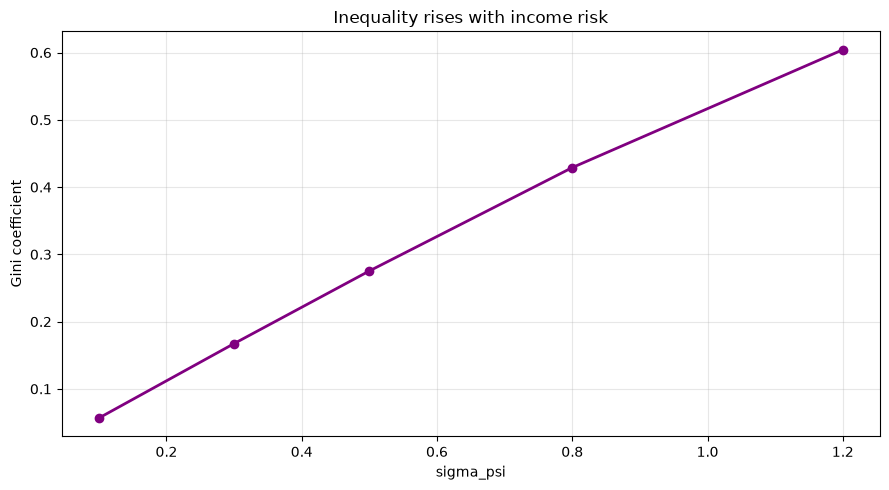

Baseline Gini: 0.276
More risk Gini: 0.604


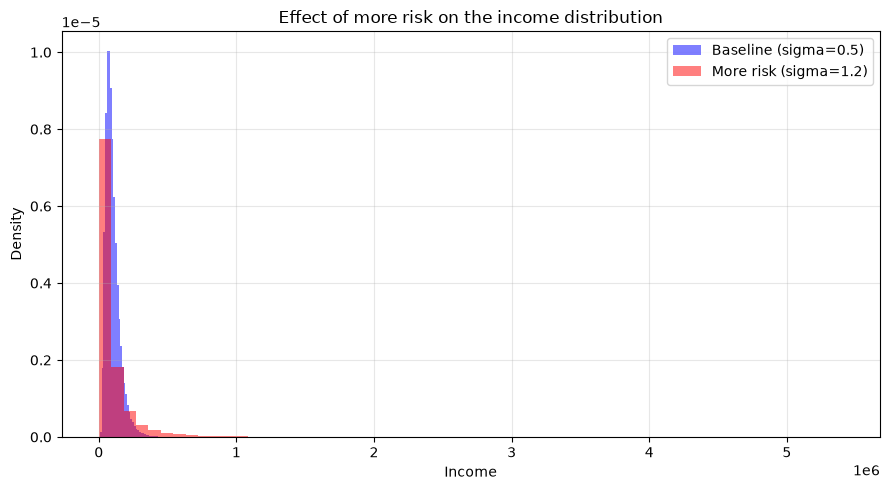

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.stats import norm  # normal distribution

## ---------------------------------------------------------
## 2.1 The model
## ---------------------------------------------------------

# Parameters of the simulation
N = 100_000
seed = 1234
sigma_psi = 0.5
y0 = 100_000

# Create a local random number generator for reproducible results
rng = np.random.default_rng(seed)

# Draw the multiplicative income shock
# This gives a lognormal distribution with mean approximately 1
psi = rng.lognormal(mean=-0.5 * sigma_psi**2, sigma=sigma_psi, size=N)

# Simulate individual income as baseline income times shock
income = y0 * psi

print(f"Mean income: {income.mean():.2f}")
print(f"Median income: {np.median(income):.2f}")
print(f"Std. dev. of income: {income.std():.2f}")
print(f"Min income: {income.min():.2f}")
print(f"Max income: {income.max():.2f}")

# Optional: inspect the distribution of income
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(income, bins=80, density=True, alpha=0.7, color="steelblue")
ax.set_title("Simulated income distribution")
ax.set_xlabel("Income")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ---------------------------------------------------------
## 2.2 Simulate the income distribution
## ---------------------------------------------------------

# We keep the same model, but show a few summary statistics for the distribution
# and a distribution plot with a log-scale on the x-axis for clarity.

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(income, bins=80, density=True, alpha=0.7, color="darkgreen")
ax.set_title("Distribution of simulated income")
ax.set_xlabel("Income")
ax.set_ylabel("Density")
ax.set_xscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ---------------------------------------------------------
## 2.3 Compute the Gini coefficient
## ---------------------------------------------------------

# Gini coefficient for a positive income distribution.
def gini(x):
    x = np.asarray(x, dtype=float)
    if x.ndim != 1:
        x = x.ravel()
    if x.size == 0:
        return np.nan
    if np.all(x == 0):
        return 0.0

    x = np.sort(x)
    n = x.size
    idx = np.arange(1, n + 1)
    numerator = 2 * np.sum(idx * x)
    denominator = n * np.sum(x)
    gini_value = numerator / denominator - (n + 1) / n
    return float(gini_value)

Gini = gini(income)
print(f"Gini coefficient: {Gini:.3f}")

# A second way: compare with the Lorenz-curve intuition for the same distribution
# This code is illustrative and not required for the assignment.
# The Gini coefficient is the area between the 45-degree line and the Lorenz curve.

sorted_income = np.sort(income)
population_share = np.linspace(0, 1, len(sorted_income))
income_share = np.cumsum(sorted_income) / np.sum(sorted_income)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(population_share, population_share, color="black", linestyle="--", label="45-degree line")
ax.plot(population_share, income_share, color="darkred", linewidth=2, label="Lorenz curve")
ax.fill_between(population_share, population_share, income_share, alpha=0.2, color="darkred")
ax.set_title("Lorenz curve")
ax.set_xlabel("Population share")
ax.set_ylabel("Income share")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ---------------------------------------------------------
## 2.4 What drives inequality?
## ---------------------------------------------------------

# To study what drives inequality, vary the dispersion of the shock sigma_psi.
# Larger sigma_psi means more dispersion in income and therefore higher inequality.

sigma_values = [0.1, 0.3, 0.5, 0.8, 1.2]
results = []

for sigma in sigma_values:
    psi_alt = rng.lognormal(mean=-0.5 * sigma**2, sigma=sigma, size=N)
    income_alt = y0 * psi_alt
    results.append({
        "sigma_psi": sigma,
        "mean_income": income_alt.mean(),
        "std_income": income_alt.std(),
        "gini": gini(income_alt)
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(results_df["sigma_psi"], results_df["gini"], marker="o", linewidth=2, color="purple")
ax.set_title("Inequality rises with income risk")
ax.set_xlabel("sigma_psi")
ax.set_ylabel("Gini coefficient")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# A simple interpretation:
# when sigma_psi is small, income differences are small and Gini is low;
# when sigma_psi is large, the right tail of the distribution becomes much thicker,
# and the Gini coefficient rises.

## ---------------------------------------------------------
## 2.5 Extension: more risk
## ---------------------------------------------------------

# Extension: compare a baseline simulation with a more risky environment.
# The idea is that greater volatility in the income shock implies a more unequal income distribution.

sigma_baseline = 0.5
sigma_more_risk = 1.2

rng_ext = np.random.default_rng(2024)
psi_baseline = rng_ext.lognormal(mean=-0.5 * sigma_baseline**2, sigma=sigma_baseline, size=N)
psi_risk = rng_ext.lognormal(mean=-0.5 * sigma_more_risk**2, sigma=sigma_more_risk, size=N)

income_baseline = y0 * psi_baseline
income_risk = y0 * psi_risk

print(f"Baseline Gini: {gini(income_baseline):.3f}")
print(f"More risk Gini: {gini(income_risk):.3f}")

# Plot both distributions in one figure
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(income_baseline, bins=60, density=True, alpha=0.5, color="blue", label=f"Baseline (sigma={sigma_baseline})")
ax.hist(income_risk, bins=60, density=True, alpha=0.5, color="red", label=f"More risk (sigma={sigma_more_risk})")
ax.set_title("Effect of more risk on the income distribution")
ax.set_xlabel("Income")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final takeaway:
# More risk (larger sigma_psi) creates a thicker upper tail in the distribution,
# which increases the dispersion in incomes and therefore the Gini coefficient.